<a href="https://colab.research.google.com/github/Mariano-ds/centollas2026/blob/main/1.trabajo_comun_tp2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<a href="https://colab.research.google.com/github/Mariano-ds/centollas2026/blob/main/trabajo_comun/entregas/trabajo_comun_tp2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Diplomatura en Ciencia de Datos, Aprendizaje Automático y sus Aplicaciones**

## **Edición 2026**

### Parte 2: Análisis exploratorio y curación de datos

---
## Mentoría 15: *¿Cuándo y dónde pescar Centollas en el Canal Beagle?*

**Objetivo**: responder al menos tres de las preguntas planteadas por el grupo en el trabajo práctico 1.

Se espera un manejo más avanzado del set de datos, en donde el grupo de trabajo relacione las distintas columnas del dataset (variables) para responder preguntas con una complejidad mayor que la de realizar una mera descripción.

Cada respuesta a cada pregunta debe contener los siguientes apartados para considerarse completa:

1. **Planteo de la pregunta.** Se deben incluir las implicancias o las consecuencias de poder responderla. Por ejemplo, si la pregunta es ¿cuándo presentan mayor cantidad de huevos las hembras de cada una de las especies? Tiene implicancia directa en el manejo pesquero de la especie. Explicitar.

2. **Desarrollo del paso a paso que se hizo para responder a la pregunta.** Por ejemplo, ¿cómo se consideraron los datos faltantes? ¿qué individuos se consideraron y cuáles no?

3. Al menos **un gráfico por pregunta respondida**, así como su interpretación.

In [1]:
# Librerias utilizadas
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import plotly.express as px
import numpy as np
import pandas as pd
import seaborn as sns
import missingno as msno
import re

from scipy import stats

sns.set_context('talk')
pd.options.display.max_rows = 99999
pd.options.display.max_colwidth = 400

In [2]:
# Importo dataset original
url_original_data = "https://raw.github.com/luciabergagna-jpg/centoll/main/centollas_mentoria.csv"
data_original = pd.read_csv(url_original_data, sep=';', engine='python', encoding='latin1')

In [3]:
# Cargo el CSV local guardado en Drive con datos jul97
url_jul97 = 'https://raw.github.com/Mariano-ds/centollas2026/main/datos/jul97.csv'
data_jul97 = pd.read_csv(url_jul97, sep=';', engine='python', encoding='utf-8-sig')

In [4]:
# Estandarizacion previa - nombres de columnas
data_original.columns = data_original.columns.str.strip().str.lower()
data_jul97.columns = data_jul97.columns.str.strip().str.lower()

# Concatenar los DataFrames
# axis=0 une por filas alineando automáticamente por nombre de columna
# ignore_index=True reindexa las filas de 0 a N para evitar índices repetidos
df_full = pd.concat([data_original, data_jul97], axis=0, ignore_index=True)

# Confirmación de la estructura unificada
print(f"Filas totales: {df_full.shape[0]} | Columnas totales: {df_full.shape[1]}")
df_raw = df_full.copy()
df_raw.head(2)

Filas totales: 13114 | Columnas totales: 20


,fecha,rk,tipo,localizacion,latitud,longitud,profundidad,especie,sexo,estado_caparazon,cirripedio,largo_caparazon,ancho_caparazon,largo_quela,ancho_quela,huevos,parasito,observaciones,unnamed: 18,unnamed: 19
0,ene_96,1,Captura total de 3 trampas,frente bal. Ponsatti,NaN,NaN,23.0,2,1,4.0,3,87.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,ene_96,2,Captura total de 3 trampas,frente bal. Ponsatti,NaN,NaN,23.0,2,2,3.0,2,77.1,NaN,NaN,NaN,1,NaN,NaN,NaN,NaN


### Informacion acerca de las variables

Datos genrales de las campañas:

- enero_96 > Muestreo a bordo de Wapisa, 26/01/96; WAPJAN96
- abril_96 > Muestreo a bordo de Catamarca 2/4/96
- julio_96 > Muestreo a bordo de Wapisa y Catamarca, 24 y 25.07.96; LANJUL96.WQ1
- octubre_96 > Muestreo a bordo de Catamarca, 2 y 3.10.96; CATOCT96.WQ1
- octubre_97 > Muestreo a bordo de la Catamarca el 6 y 7 de octubre de 1997
- octubre_98 > Muestreo a bordo de la Catamarca el 13 de octubre de 1998

Datos adicionales:

- julio_97

La codificación de las variables categóricas se reconstruyó a partir del protocolo de muestreo
(Lovrich, *Lithodes - Muestreo*) que documenta el criterio de toma de datos en el campo.

| Variable | Descripción | Códigos / Unidades |
|---|---|---|
| `fecha` | Temporada de muestreo | ene_96, abril_96, jul_96, oct_96, jul_97, oct_97, oct_98 |
| `rk` | Número de registro/individuo dentro de la temporada | entero |
| `tipo` | Tipo de captura y cantidad de trampas (o desembarque) del punto de muestreo | texto, p.ej. "Captura total de 3 trampas" |
| `localizacion` | Punto de referencia geográfico del muestreo | texto libre |
| `latitud`, `longitud` | Coordenadas del punto de muestreo | grados decimales |
| `profundidad` | Profundidad del punto de muestreo | metros |
| `especie` | Especie del individuo | 1 = centolla (*Lithodes santolla*), 2 = centollón (*Paralomis granulosa*) |
| `sexo` | Sexo del individuo | 1 = macho, 2 = hembra* |
| `estado_caparazon` | Estado del caparazón / epibiosis | 1 postmuda, 2 duro sin epibiontes, 3 duro con epibiontes (Spirorbis), 4 duro con epibiontes (Balanus), 5 duro con 2º caparazón visible, 6 exuvia, 30 entre estado 2 y 3 |
| `cirripedio` | Presencia/nivel de cirripedios (parásito *Briarosaccus*) | 1–3 (nivel), sufijo "p" en algunos registros |
| `largo_caparazon` | Largo del caparazón (LC) | mm |
| `ancho_caparazon` | Ancho del caparazón | mm |
| `largo_quela` | Largo de la pinza derecha | mm |
| `ancho_quela` | Ancho de la pinza derecha | mm |
| `huevos` | Estado de desarrollo de los huevos (solo hembras) | 0 sin huevos, 1 huevos sin ojos, 2 huevos sin ojos con mancha blanca, 3 huevos con ojos, 4 eclosionando, 5 cápsulas vacías (postovígera), 6 embriogénesis heterogénea, 7 trazas |
| `parasito` | Presencia de parásito *Pseudione* | 2 isopodo presente, 20 isopodo cicatriz, 3 rizocefalo presente, 30 rizocefalo cicatriz |
| `observaciones` | Notas de campo | texto libre |


In [5]:
df_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13114 entries, 0 to 13113
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   fecha             13114 non-null  object 
 1   rk                13114 non-null  int64  
 2   tipo              13114 non-null  object 
 3   localizacion      9021 non-null   object 
 4   latitud           7970 non-null   float64
 5   longitud          7970 non-null   float64
 6   profundidad       9765 non-null   float64
 7   especie           13114 non-null  int64  
 8   sexo              13114 non-null  int64  
 9   estado_caparazon  13106 non-null  float64
 10  cirripedio        1840 non-null   object 
 11  largo_caparazon   13087 non-null  float64
 12  ancho_caparazon   183 non-null    float64
 13  largo_quela       196 non-null    float64
 14  ancho_quela       198 non-null    float64
 15  huevos            3771 non-null   object 
 16  parasito          296 non-null    object

<Axes: >

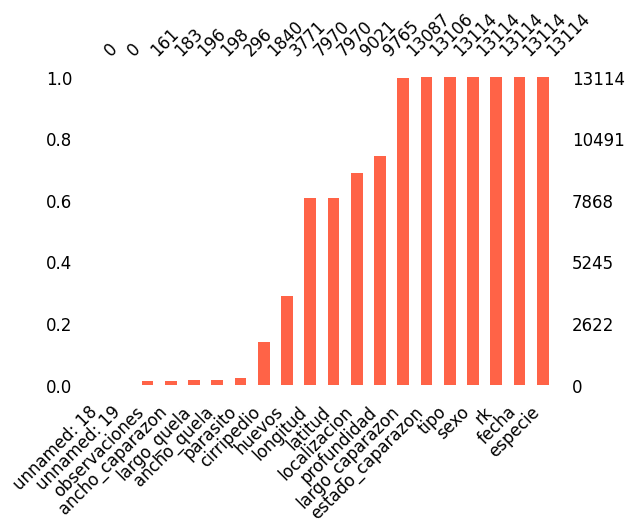

In [6]:
# Visualizacion de valores nulos
msno.bar(df_raw,figsize=(6, 4), sort="ascending",fontsize=12, color='tomato')

In [7]:
# Estudio porcentual de valores nulos
faltantes = df_raw.isnull().mean().sort_values(ascending=False) * 100
print(faltantes[faltantes > 0].round(2))

unnamed: 18         100.00
unnamed: 19         100.00
observaciones        98.77
ancho_caparazon      98.60
largo_quela          98.51
ancho_quela          98.49
parasito             97.74
cirripedio           85.97
huevos               71.24
latitud              39.23
longitud             39.23
localizacion         31.21
profundidad          25.54
largo_caparazon       0.21
estado_caparazon      0.06
dtype: float64


## 1 Limpieza inicial del dataset  

Se eliminan las columnas `unnamed: 18` y `unnamed: 19` ya que no aportan información.

In [8]:
# Se eliminan columnas vacías generadas por separadores sobrantes al final de cada fila
df_raw.drop(columns=['unnamed: 18', 'unnamed: 19'], inplace=True)
df_raw.dropna(subset=['largo_caparazon'],how='any',inplace=True)
print(f"Filas: {df_raw.shape[0]:,} | Columnas: {df_raw.shape[1]}")

Filas: 13,087 | Columnas: 18


Las columnas más relevantes para nuestro estudio serán las asociadas a la cantidad de cangrejos en la muestra, su ubicación temporal y espacial, seguido de las características físicas de los mismos.

Puesto que estamos interesados en estudiar la distribución espacial, se eliminan las entradas con localizacion, latitud y altitud simultaneamente nulas. Estos casos no permiten inferir de ninguna manera robusta dónde se realizó la pesca, por lo que se descartan del estudio.



In [9]:
# Elimina la fila SOLO si latitud, longitud y localizacion son NaN simultáneamente
df_raw.dropna(subset=['latitud', 'longitud', 'localizacion'],how='all',inplace=True)
print(f"Filas: {df_raw.shape[0]:,} | Columnas: {df_raw.shape[1]}")

Filas: 9,105 | Columnas: 18


Debido al alto porcentaje de entradas nulas, se descartan las columnas `ancho_caparazon`, `largo_quela` y `ancho_quela`, pues no permiten sacar conclusiones sobre la muestra.


In [10]:
df_raw.drop(columns=['ancho_caparazon', 'largo_quela', 'ancho_quela'], inplace=True)

Se procede a limpiar la columna de `tipo` de captura, extrayendo cuando sea posible la cantidad de trampas empleadas durante cada campaña. Esto permite calcular el esfuerzo de captura posteriormente:

In [11]:
df_raw['tipo'].value_counts()

,count
tipo,
Captura total de 4 trampas,895
Captura total de 3 trampas,893
Captura total de 10 trampas,813
Captura total de 2 trampas,709
Captura total de 1 trampa,618
Captura total de 5 trampas,589
Captura total de 2.5 trampas,588
Captura total de 0.75 trampas,461
Captura total de 0.8 trampas,409


In [12]:
def extraer_num_trampas(tipo_str):
    """
    Extrae el número de trampas vinculando explícitamente la cantidad
    con los términos 'trampa' o 'linea'.
    """
    if pd.isna(tipo_str):
        return np.nan

    texto = str(tipo_str).lower()

    # 1. Patrón con número ANTES del término (ej: "10 trampas", "captura de 2 líneas")
    match_antes = re.search(r'(\d+\.?\d*)\s*(?:de\s*)?(trampa|línea|linea)', texto)

    # 2. Patrón con número DESPUÉS del término (ej: "trampas: 10", "línea 2")
    match_despues = re.search(r'(trampa|línea|linea)s?\s*(?::\s*|de\s*)?(\d+\.?\d*)', texto)

    if match_antes:
        numero = float(match_antes.group(1))
        unidad = match_antes.group(2)
    elif match_despues:
        unidad = match_despues.group(1)
        numero = float(match_despues.group(2))
    else:
        # Casos como "Captura total trampas wp 149" (sin cantidad especificada) o muestreos
        return np.nan

    # 3. Conversión de unidades (1 línea = 10 trampas)
    if 'linea' in unidad or 'línea' in unidad:
        return numero * 10.0
    return numero

### Extracción del esfuerzo de pesca desde `tipo`

La columna `tipo` codifica el esfuerzo de pesca como texto libre (ej. *"Captura total de 3 trampas"*,
*"Captura total de 8 líneas"*). Para poder calcular índices de abundancia relativa (CPUE, IAR) es
necesario extraer ese número y expresarlo en una unidad común.

**Conversión de unidades:** 1 línea = 10 trampas. Dato provisto por la mentora (no documentado en el
protocolo de muestreo original), utilizado para poder comparar registros de ambas unidades bajo un
mismo esfuerzo estandarizado.

Los registros de `tipo` que no declaran ninguna cantidad de esfuerzo (ej. desembarques, muestreos de
cubierta, "Captura total trampas wp 149" sin número) quedan sin dato de `num_trampas` y por lo tanto
excluidos de cualquier cálculo de esfuerzo — no forman parte de una limpieza arbitraria, sino de
categorías de `tipo` genuinamente distintas a una captura por trampa.

In [13]:
# Aplicar función
df_raw['num_trampas'] = df_raw['tipo'].apply(extraer_num_trampas)

n_total = len(df_raw)
n_validos = df_raw['num_trampas'].notna().sum()
n_excluidos = n_total - n_validos

print("=="*50)
print(f" Registros con esfuerzo de pesca identificable: {n_validos} ({n_validos/n_total*100:.1f}%)")
print(f" Registros excluidos del cálculo de IAR (índice de abundancia relativa): {n_excluidos} ({n_excluidos/n_total*100:.1f}%)")
print("=="*50)

print("\nCategorías excluidas (sin equivalente en trampas):")
print(df_raw[df_raw['num_trampas'].isna()]['tipo'].value_counts())

 Registros con esfuerzo de pesca identificable: 8865 (97.4%)
 Registros excluidos del cálculo de IAR (índice de abundancia relativa): 240 (2.6%)

Categorías excluidas (sin equivalente en trampas):
tipo
Captura total trampas wp 149    110
Captura por la Wapisa            75
Muestreo de cubierta 3           55
Name: count, dtype: int64


El dataframe de trabajo es el resultado de concatenar dos registros diferentes: al conjunto de datos originales se suma la campaña de jul97 provista posteriormente por nuestra mentora. Para estudiar la evolución temporal de los registros, es necesario ordenar las entradas correctamente.

A continuación se ordena el dataframe de manera que las campañas se sucedan coherentemente en el tiempo.

### Inclusión de la campaña jul_97 en el análisis principal

El dataset `jul97.csv`, provisto por la mentora con posterioridad al entregable del TP1, es de
carácter **opcional** según lo indicado — su incorporación no afecta la evaluación del trabajo en
ningún sentido, sea que se use o no.

Se decide incorporarlo al análisis principal (en vez de tratarlo como una exploración aparte) porque
permite poner a prueba directamente la hipótesis planteada por la mentoría: la proporción
inusualmente baja de hembras ovígeras observada en **oct_96** podría estar asociada a una anomalía
ambiental ocurrida en el invierno de 1995 (nevada extrema en Ushuaia), que habría afectado la
fecundación de esa cohorte específica.

Dado que el ciclo reproductivo del centollón dura entre 18 y 22 meses, contar con un segundo registro
de **julio** (jul_97, además de jul_96) permite comparar dos temporadas equivalentes en el calendario
pero pertenecientes a distintas cohortes reproductivas. Si la caída de hembras ovígeras fuera un
patrón estacional esperable, jul_97 debería mostrar una proporción similar a jul_96. Si en cambio
jul_97 muestra una proporción sustancialmente mayor, esto sería consistente con la hipótesis de una
anomalía puntual en 1995-96, y no con un patrón estacional recurrente.

Esta comparación se desarrolla en la interpretación de la sección 5.1

In [14]:
# Definicion de la prioridad cronologica de las campañas
orden_campanas = {
    'ene_96': 1,
    'abril_96': 2,
    'jul_96': 3,
    'oct_96': 4,
    'jul_97': 5,
    'oct_97': 6,
    'oct_98': 7
}

# Se convierte a categorica y se ordena por fecha
df_raw['fecha'] = pd.Categorical(df_raw['fecha'], categories=orden_campanas, ordered=True)

# Se ordena con 'key' y se reinicia el índice
#df_raw = df_raw.sort_values(by='fecha', key=lambda x: x.map(orden_campanas)).reset_index(drop=True)

El porcentaje de nulos del dataframe de trabajo actualmente es el siguiente:

In [15]:
print("="*50)
print("Resumen de limpieza inicial - Estado actual del df")
print("="*50)

print(f"\nFilas: {df_raw.shape[0]:,} | Columnas: {df_raw.shape[1]}\n")

# Estudio porcentual de valores nulos
faltantes = df_raw.isnull().mean().sort_values(ascending=False) * 100
print(faltantes[faltantes > 0].round(2))

Resumen de limpieza inicial - Estado actual del df

Filas: 9,105 | Columnas: 16

observaciones       98.58
parasito            97.25
cirripedio          86.23
huevos              62.47
longitud            12.73
latitud             12.73
num_trampas          2.64
profundidad          1.50
localizacion         1.21
estado_caparazon     0.02
dtype: float64


### 1.1 Composición del dataset limpio

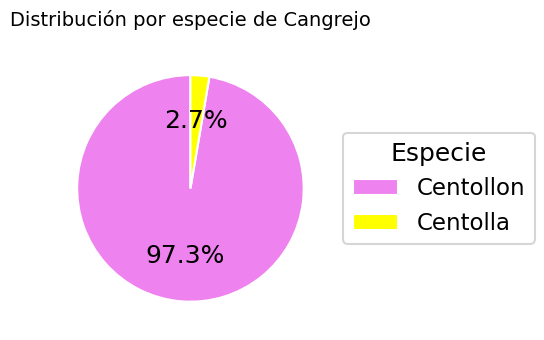

In [16]:
# @title
# Diccionario de mapeo
mapa_especies = {
    1: 'Centolla',
    2: 'Centollon',
    '1': 'Centolla',
    '2': 'Centollon',
}

# Conteo de valores
conteo = df_raw['especie'].value_counts()

# Mapear los índices traducidos para la leyenda
etiquetas = [mapa_especies.get(x, str(x)) for x in conteo.index]

plt.figure(figsize=(5, 4))

# Generar el gráfico asignando los elementos a variables para la leyenda
wedges, texts, autotexts = plt.pie(
    conteo,
    autopct='%1.1f%%',
    colors=sns.color_palette(['violet', 'yellow']),
    startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 1.5},
)

# Agregar la leyenda con las nuevas etiquetas
plt.legend(
    wedges,
    etiquetas,
    title='Especie',
    loc='center left',
    bbox_to_anchor=(1, 0, 0.5, 1),
)

plt.title('Distribución por especie de Cangrejo', fontsize=14, pad=15)
plt.tight_layout()
plt.show()

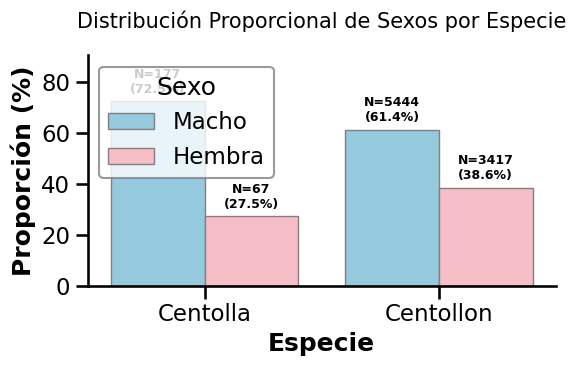

In [17]:
# @title
# Mapeo de codificación
mapa_sexo = {
    1: 'Macho',
    2: 'Hembra'
}

# Aplicar mapeo a una copia del DataFrame
df_plot = df_raw.copy()
df_plot['especie_nom'] = df_plot['especie'].map(mapa_especies)
df_plot['sexo_nom'] = df_plot['sexo'].map(mapa_sexo)

# Calcular Conteos (N) y Porcentajes dentro de cada especie
ct_counts = pd.crosstab(df_plot['especie_nom'], df_plot['sexo_nom'])
ct_pct = (
    pd.crosstab(
        df_plot['especie_nom'], df_plot['sexo_nom'], normalize='index'
    )
    * 100
)

# Convertir a formato largo para Seaborn
df_counts = ct_counts.reset_index().melt(
    id_vars='especie_nom', value_name='n_muestras'
)
df_pct = ct_pct.reset_index().melt(
    id_vars='especie_nom', value_name='porcentaje'
)
df_final = pd.merge(df_counts, df_pct, on=['especie_nom', 'sexo_nom'])

# Paleta exacta: Celeste para Macho, Rosa para Hembra
paleta_sexo = {'Macho': '#87CEEB', 'Hembra': '#FFB6C1'}  # Skyblue y Lightpink

orden_especie = ['Centolla', 'Centollon']
orden_sexo = ['Macho', 'Hembra']

# Crear el gráfico
plt.figure(figsize=(6, 4))
ax = sns.barplot(
    data=df_final,
    x='especie_nom',
    y='porcentaje',
    hue='sexo_nom',
    order=orden_especie,
    hue_order=orden_sexo,
    palette=paleta_sexo,
    edgecolor='gray',
    linewidth=1,
)

# Agregar el número de muestras (N) sobre cada barra
# (se usa un orden explícito para emparejar cada container con su categoría real,
# en vez de container.get_label(), que no devuelve 'Macho'/'Hembra')
for sexo_cat, container in zip(orden_sexo, ax.containers):
    sub_df = (
        df_final[df_final['sexo_nom'] == sexo_cat]
        .set_index('especie_nom')
        .reindex(orden_especie)
    )
    etiquetas = [
        f"N={int(row['n_muestras'])}\n({row['porcentaje']:.1f}%)"
        for _, row in sub_df.iterrows()
    ]
    ax.bar_label(
        container, labels=etiquetas, padding=4, fontsize=9, fontweight='bold'
    )

# Estética y Caja de Leyenda
plt.title('Distribución Proporcional de Sexos por Especie', fontsize=15, pad=20)
plt.xlabel('Especie', fontweight='bold')
plt.ylabel('Proporción (%)', fontweight='bold')
plt.ylim(
    0, df_final['porcentaje'].max() * 1.25
)  # Margen superior para los textos

# Caja de leyenda
plt.legend(
    title='Sexo',
    loc='upper left',
    frameon=True,
    facecolor='white',
    edgecolor='gray',
)

sns.despine()
plt.tight_layout()
plt.show()

## 2 Corrección de columnas numéricas y categóricas

Estudiemos las variables que quedan con dtype str:  cirripedio, huevos y parasito.

Según la descripcion de los features provistos junto al dataset, hay una serie de columnas cuyos tipos son incorrectos. `estado_caparazon` es flotante en lugar de entero, y las columnas `cirripedio`, `huevos` y `parasito` figuran como str, en lugar de ser variables enteras.

In [18]:
# Copia posterior a la limpieza inicial
df_clean = df_raw.copy()

### 2.1 `estado_caparazon`

La codificación de esta variable es:

- 1 postmuda,
- 2 duro sin epibiontes,
- 3 duro con epibiontes (Spirorbis),
- 4 duro con epibiontes (Balanus),
- 5 duro con 2º caparazón visible,
- 6 exuvia,
- 30 entre estado 2 y 3.

In [19]:
df_clean['estado_caparazon'].value_counts()

,count
estado_caparazon,
3.0,7602
4.0,1207
30.0,153
2.0,130
1.0,7
6.0,2
5.0,2


Los registros no tienen errores en esta variable. No se efectuaron cambios.

### 2.2 `cirripedio`

La codificación de esta variable es:

1–3 (tamaño), sufijo "p" en algunos registros indica presencia en patas. Caso contrario, presencia en caparazón.

NOTA: Los valores decimales reportados significan presencia de cirripedios de diversos tamaños. Por ejemplo, 1.2 se interpreta como que había tamaño 1 y tamaño 2 en caparazón.

In [20]:
df_clean['cirripedio'].value_counts()

,count
cirripedio,
2,797
2.0,370
1,45
3,18
2.3,11
1.0,4
3.0,4
2p,2
1p,1


Debido a que el sufijo 'p' se presentó en únicamente 3 de las >1250 observaciones no nulas, se descartó la creación de una variable indicadora binaria para evitar problemas de varianza nula y desbalance extremo en los pliegues de validación cruzada. Para preservar la integridad del dataset, la variable fue consolidada en su escala numérica base ( 1,2,3 ) removiendo el sufijo marginal. Se conserva solo la caracterizacion de la presencia de cirripedios y no se indica en qué parte del individuo se encuentra, pues para nuestro posterior análisis no resulta relevante tal nivel de detalle.

Se corrije así el tipo de datos str -> float.

In [21]:
# Diccionario de correcciones:
correcciones_cirripedio = {
    '2p': '2',
    '1p': '1'
}

# Aplicar el reemplazo
df_clean['cirripedio'] = df_clean['cirripedio'].replace(correcciones_cirripedio)
df_clean['cirripedio'] = df_clean['cirripedio'].apply(lambda x: float(x))
df_clean['cirripedio'].value_counts()

,count
cirripedio,
2.00,1169
1.00,50
3.00,22
2.30,11
1.23,1
1.20,1


### 2.3 `parasitos`

La codificación de esta variable es:

- 2 isopodo presente,
- 20 isopodo cicatriz,
- 3 rizocefalo presente,
- 30 rizocefalo cicatriz



In [22]:
df_clean['parasito'].value_counts()

,count
parasito,
20,169
2,34
3,18
20.0,16
30,9
2.0,2
"3,20",1
"30,20",1


In [23]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9105 entries, 0 to 12868
Data columns (total 16 columns):
 #   Column            Non-Null Count  Dtype   
---  ------            --------------  -----   
 0   fecha             9105 non-null   category
 1   rk                9105 non-null   int64   
 2   tipo              9105 non-null   object  
 3   localizacion      8995 non-null   object  
 4   latitud           7946 non-null   float64 
 5   longitud          7946 non-null   float64 
 6   profundidad       8968 non-null   float64 
 7   especie           9105 non-null   int64   
 8   sexo              9105 non-null   int64   
 9   estado_caparazon  9103 non-null   float64 
 10  cirripedio        1254 non-null   float64 
 11  largo_caparazon   9105 non-null   float64 
 12  huevos            3417 non-null   object  
 13  parasito          250 non-null    object  
 14  observaciones     129 non-null    object  
 15  num_trampas       8865 non-null   float64 
dtypes: category(1), float64(7), 

Dado que las muestras con doble categoría representaban únicamente 2 de los 9105 registros totales conservados luego de la limpieza inicial, se descartó la implementación de un esquema multi-etiqueta para evitar problemas de varianza por categorías atípicas. En su lugar, se procedió a reasignar dichas entradas a su categoría principal.

Se reporta la presencia del parásito frente a la cicatriz en el primer caso; y se reporta la cicatriz de la clase minoritaria en el segundo caso.

In [24]:
# Diccionario de correcciones:
correccion_parasito = {
    '3,20': '3', # Priorizo el parasito presente
    '30,20': '30'
}

# Aplicar el reemplazo
df_clean['parasito'] = df_clean['parasito'].replace(correccion_parasito)
df_clean['parasito'] = df_clean['parasito'].apply(lambda x: float(x))
df_clean['parasito'].value_counts()

,count
parasito,
20.0,185
2.0,36
3.0,19
30.0,10


### 2.4 `huevos`

La codificación de esta variable es:

- 0 sin huevos,
- 1 huevos sin ojos,
- 2 huevos sin ojos con mancha blanca,
- 3 huevos con ojos,
- 30 comienzo del estadío 3*,
- 4 eclosionando,
- 40 comienzo del estadío 4*,
- 5 cápsulas vacías (postovígera),
- 6 embriogénesis heterogénea,
- 7 trazas.

Nota: (*) fue información provista por nuestra mentora, no declarada en la documentación original del dataset.

In [25]:
df_clean['huevos'].value_counts()

,count
huevos,
1,1099
0,727
30,455
3.0,231
1.0,217
5,201
6,95
7,89
3,75


In [26]:
# Muestra el registro que tiene huevos = po
df_clean[df_clean['huevos'] == 'po']

,fecha,rk,tipo,localizacion,latitud,longitud,profundidad,especie,sexo,estado_caparazon,cirripedio,largo_caparazon,huevos,parasito,observaciones,num_trampas
1966,abril_96,163,Captura total de 2 trampas,cerca de Haskesheska,NaN,NaN,30.0,2,2,3.0,2.0,80.7,po,NaN,NaN,2.0


Las correcciones numéricas sobre los valores observados consisten en unificar tipos de datos, pasando enteros a reales.

Para hacer las correcciones de texto, se estudian en detalle estos casos.



In [27]:
# Estudio de registros particulares huevos = conojos
df_clean[df_clean['huevos'] == 'conojos']

,fecha,rk,tipo,localizacion,latitud,longitud,profundidad,especie,sexo,estado_caparazon,cirripedio,largo_caparazon,huevos,parasito,observaciones,num_trampas
1876,abril_96,73,Captura total de 2 trampas,cerca de Haskesheska,NaN,NaN,30.0,2,2,4.0,2.0,73.2,conojos,NaN,NaN,2.0
1909,abril_96,106,Captura total de 2 trampas,cerca de Haskesheska,NaN,NaN,30.0,2,2,4.0,2.0,71.8,conojos,NaN,NaN,2.0


In [28]:
# Estudio de registros particulares huevos = 7 en 1
df_clean[df_clean['huevos'] == '7 en 1']

,fecha,rk,tipo,localizacion,latitud,longitud,profundidad,especie,sexo,estado_caparazon,cirripedio,largo_caparazon,huevos,parasito,observaciones,num_trampas
1814,abril_96,11,Captura total de 2 trampas,cerca de Haskesheska,NaN,NaN,30.0,2,2,3.0,NaN,92.8,7 en 1,NaN,NaN,2.0


In [29]:
# Estudio de registro particular huevos = po
df_clean[df_clean['huevos'] == 'po']

,fecha,rk,tipo,localizacion,latitud,longitud,profundidad,especie,sexo,estado_caparazon,cirripedio,largo_caparazon,huevos,parasito,observaciones,num_trampas
1966,abril_96,163,Captura total de 2 trampas,cerca de Haskesheska,NaN,NaN,30.0,2,2,3.0,2.0,80.7,po,NaN,NaN,2.0


Se observa que todos los registros atípicos corresponden a la misma campaña y al mismo punto de pesca. Es posible que haya habido desinformación de la codificación de esta variable.

Las correcciones realizadas son las siguientes:

- Los registros cuyo valor es `conojos` se rectifican a 3, interpretando su texto literalmente como "con ojos".

- Los registros cuyo valor es `7 en 1` se rectifican a 1, interpretando su texto una observación sobre la cantidad de huevos sin ojos realizada fuera de su columna homónima.

- Los registros cuyo valor es `po` se descartan por falta de información.

In [30]:
# Registros de hembras cerca de Haskesheska en abril del 96
df_clean[(df_clean['localizacion'] == 'cerca de Haskesheska') & (df_clean['fecha'] == 'abril_96') & (df_clean['sexo'] == 2)]

,fecha,rk,tipo,localizacion,latitud,longitud,profundidad,especie,sexo,estado_caparazon,cirripedio,largo_caparazon,huevos,parasito,observaciones,num_trampas
1814,abril_96,11,Captura total de 2 trampas,cerca de Haskesheska,NaN,NaN,30.0,2,2,3.0,NaN,92.8,7 en 1,NaN,NaN,2.0
1815,abril_96,12,Captura total de 2 trampas,cerca de Haskesheska,NaN,NaN,30.0,2,2,3.0,NaN,84.1,1,NaN,NaN,2.0
1823,abril_96,20,Captura total de 2 trampas,cerca de Haskesheska,NaN,NaN,30.0,2,2,3.0,NaN,68.9,0,NaN,NaN,2.0
1827,abril_96,24,Captura total de 2 trampas,cerca de Haskesheska,NaN,NaN,30.0,2,2,3.0,1.0,71.9,1,NaN,NaN,2.0
1831,abril_96,28,Captura total de 2 trampas,cerca de Haskesheska,NaN,NaN,30.0,2,2,3.0,NaN,68.6,1,NaN,NaN,2.0
1834,abril_96,31,Captura total de 2 trampas,cerca de Haskesheska,NaN,NaN,30.0,2,2,3.0,NaN,74.3,1,NaN,NaN,2.0
1837,abril_96,34,Captura total de 2 trampas,cerca de Haskesheska,NaN,NaN,30.0,2,2,3.0,NaN,77.8,1,NaN,NaN,2.0
1839,abril_96,36,Captura total de 2 trampas,cerca de Haskesheska,NaN,NaN,30.0,2,2,3.0,NaN,62.4,1,NaN,NaN,2.0
1842,abril_96,39,Captura total de 2 trampas,cerca de Haskesheska,NaN,NaN,30.0,2,2,3.0,NaN,72.8,1,NaN,NaN,2.0
1850,abril_96,47,Captura total de 2 trampas,cerca de Haskesheska,NaN,NaN,30.0,2,2,3.0,NaN,73.2,1,NaN,NaN,2.0


Se realizan las correcciones mencionadas antes

In [31]:
# Descarte de huevos = po
df_clean = df_clean[df_clean['huevos'] != 'po']

# Diccionario de correcciones:
correccion_huevos = {
    # Corrección de texto
    'conojos': '3',
    '7 en 1': '1'
}

# Aplicar el reemplazo
df_clean['huevos'] = df_clean['huevos'].replace(correccion_huevos)
df_clean['huevos'] = df_clean['huevos'].apply(lambda x: float(x))
df_clean['huevos'].value_counts()

,count
huevos,
1.0,1317
0.0,799
30.0,473
3.0,308
5.0,265
7.0,107
6.0,97
4.0,39
40.0,10


## 3 Segmentación del estudio


Si bien el proyecto se llama _"¿Cuándo y dónde pescar centollas?"_, el dataset mezcla dos especies con historias biológicas y pesqueras distintas: Lithodes santolla (centolla, especie de mayor valor comercial) y Paralomis granulosa (centollón, mucho más abundante pero de menor valor comercial). En 1.1 se observa que las centollas representan menos del 3% de registros totales. Veamos cómo esta especie fue capturada a lo largo de las distintas temporadas

### 3.1 Con los datos disponibles, ¿es posible identificar menor presencia de centollas?

Si una de las dos especies estuviera perdiendo presencia campaña a campaña, sería una señal temprana de sobreexplotación. Este estudio representa una ventaja frente a un análisis orientado a cada especie por separado ya que no sería posible hacer tal comparación relativa.

Para responder a la pregunta planteada, se cuenta la cantidad de individuos registrados por campaña y especie, y se calcula además el porcentaje que representa la centolla sobre el total muestreado en cada campaña para ver si su participación relativa cambia.

In [32]:
# Mapeo nombres de especies (1: L. santolla, 2: P. granulosa)
mapa_especies = {1: 'centolla', 2: 'centollon'}
especie_nom = df_clean['especie'].map(mapa_especies).fillna(df_clean['especie'])

# Genera tabla cruzada con conteos absolutos
resumen = pd.crosstab(df_clean['fecha'], especie_nom)

# Calculo Total y Porcentaje consolidado en la misma tabla
resumen['Total'] = resumen.sum(axis=1)
resumen['% centolla'] = (resumen['centolla'] / resumen['Total'] * 100).round(2)

# 5. Salida limpia formateada
print("=== COMPOSICIÓN DE CAPTURAS Y PARTICIPACIÓN DE CENTOLLAS POR CAMPAÑA ===")
print(resumen.to_string())

=== COMPOSICIÓN DE CAPTURAS Y PARTICIPACIÓN DE CENTOLLAS POR CAMPAÑA ===
especie   centolla  centollon  Total  % centolla
fecha                                           
ene_96           1        895    896        0.11
abril_96         0        163    163        0.00
jul_96          39       1631   1670        2.34
oct_96         103       1316   1419        7.26
jul_97           8       1453   1461        0.55
oct_97           4       1791   1795        0.22
oct_98          89       1611   1700        5.24


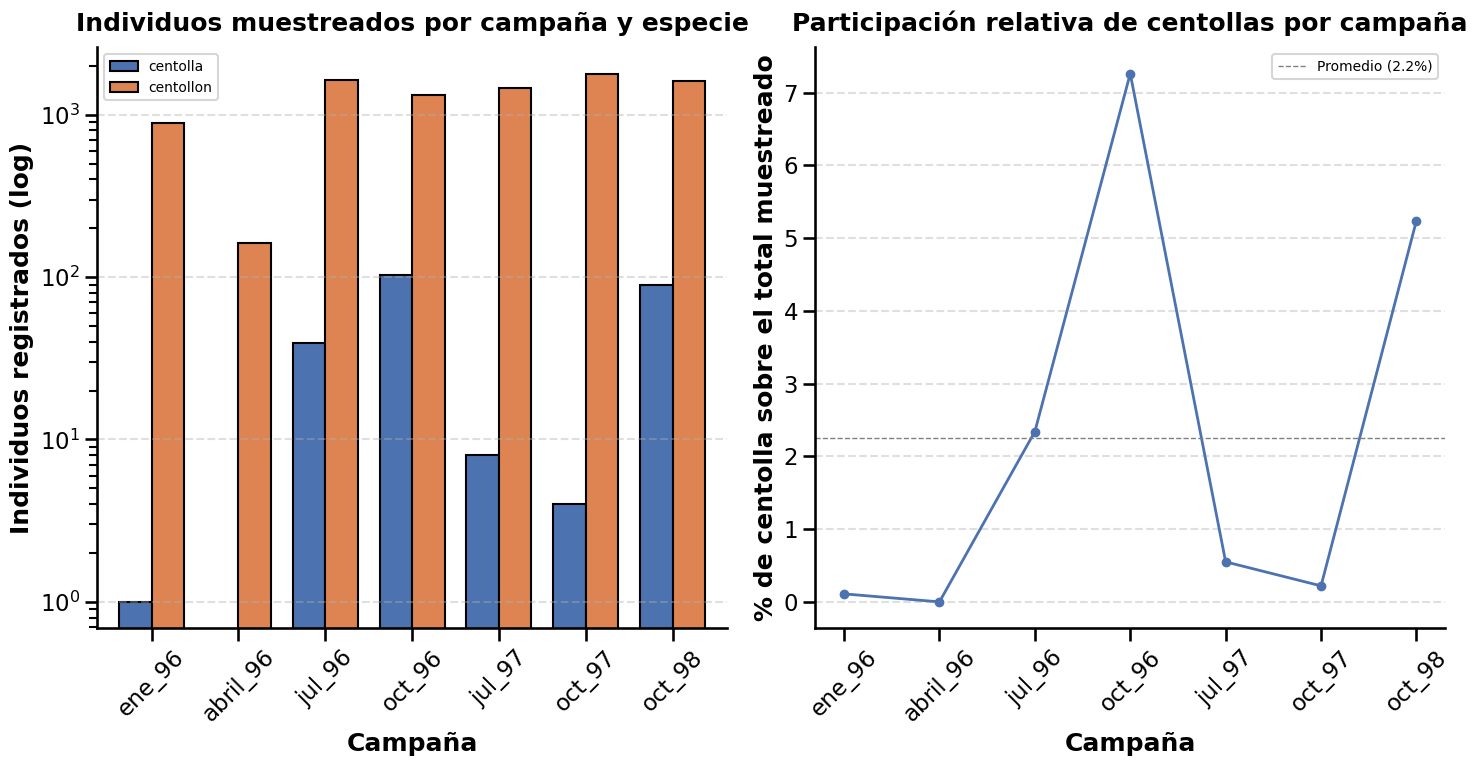

In [33]:
# @title

# Tabla cruzada: fecha y nombre de especie
tab_especie = pd.crosstab(df_clean['fecha'], especie_nom)
share_centolla = (tab_especie['centolla'] / tab_especie.sum(axis=1) * 100).round(2)

# Grafico de dos paneles
fig, axes = plt.subplots(1, 2, figsize=(15, 8))

# Panel Izquierdo: Frecuencia absoluta (escala logaritmica)
tab_especie.plot(
    kind='bar',
    ax=axes[0],
    color=['#4c72b0', '#dd8452'],
    edgecolor='black',
    width=0.75
)
axes[0].set_yscale('log')
axes[0].set_ylabel('Individuos registrados (log)', fontweight='bold')
axes[0].set_xlabel('Campaña', fontweight='bold')
axes[0].set_title('Individuos muestreados por campaña y especie', fontweight='bold', pad=12)
axes[0].legend(title='', fontsize=10)
axes[0].tick_params(axis='x', rotation=45)
axes[0].grid(axis='y', linestyle='--', alpha=0.4)

# Panel Derecho: Proporcion relativa de centollas
axes[1].plot(
    share_centolla.index,
    share_centolla.values,
    marker='o',
    color='#4c72b0',
    linewidth=2,
    markersize=6
)
axes[1].set_ylabel('% de centolla sobre el total muestreado', fontweight='bold')
axes[1].set_xlabel('Campaña', fontweight='bold')
axes[1].set_title('Participación relativa de centollas por campaña', fontweight='bold', pad=12)
axes[1].tick_params(axis='x', rotation=45)
axes[1].axhline(
    share_centolla.mean(),
    color='gray',
    linestyle='--',
    linewidth=1,
    label=f'Promedio ({share_centolla.mean():.1f}%)'
)
axes[1].legend(fontsize=10)
axes[1].grid(axis='y', linestyle='--', alpha=0.4)

sns.despine()
plt.tight_layout()
plt.show()

El siguiente gráfico muestra en detalle la proporción de centollas hembras y machos en cada campaña

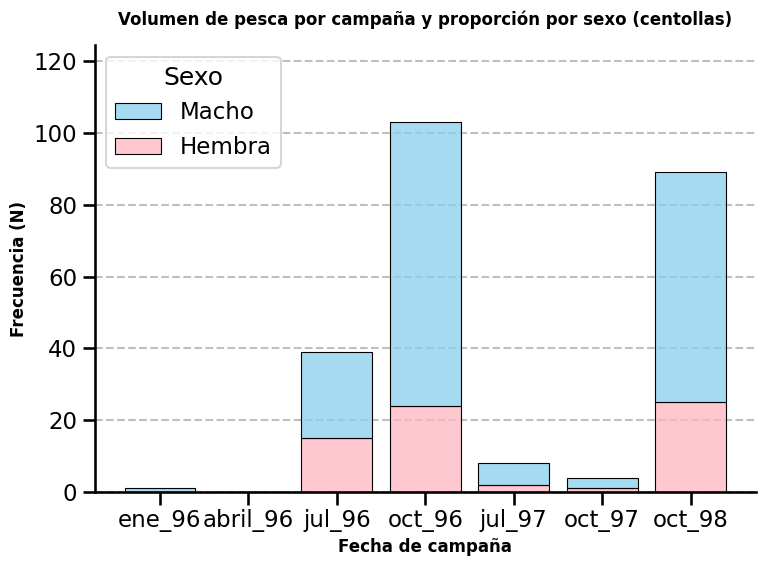

In [34]:
# @title

# Copia de trabajo, enfoque en centollas
df_plot = df_clean[df_clean['especie'] == 1].copy()

# 1. Mapear la columna sexo (1: Macho, 2: Hembra)
mapa_sexo = {1: 'Macho', 2: 'Hembra'}
df_plot['sexo_nom'] = df_plot['sexo'].map(mapa_sexo).fillna(df_plot['sexo'])

# 3. Mapeo de colores específicos: Celeste (#87CEEB) para Machos, Rosa (#FFB6C1) para Hembras
paleta_sexo = {'Macho': '#87CEEB', 'Hembra': '#FFB6C1'}

plt.figure(figsize=(8, 6))

# 4. Gráfico de barras apiladas mediante histplot
ax = sns.histplot(
    data=df_plot,
    x='fecha',
    hue='sexo_nom',
    hue_order=['Macho', 'Hembra'],
    multiple='stack',
    palette=paleta_sexo,
    shrink=0.8,
    edgecolor='black',
    linewidth=0.8
)

# 6. Ajuste de escala vertical y estética general
plt.ylim(0, ax.get_ylim()[1] * 1.15)
plt.title('Volumen de pesca por campaña y proporción por sexo (centollas)', fontsize=12, fontweight='bold', pad=15)
plt.xlabel('Fecha de campaña', fontweight='bold', fontsize=12)
plt.ylabel('Frecuencia (N)', fontweight='bold', fontsize=12)

# Ajustar etiquetas de la leyenda
sns.move_legend(ax, "upper left", title="Sexo", frameon=True)

sns.despine(top=True, right=True)
ax.set_axisbelow(True)
plt.grid(axis='y', linestyle='--', alpha=0.5, color='gray')
plt.tight_layout()
plt.show()

**Conclusiones:**

Se observa que sólo las campañas de octubre del 96 y del 98 tuvieron una pesca de más de 80 centollas, y en ningún caso la cantidad de hembras superó los 30 individuos.

No se identifica una tendencia claramente creciente o decreciente de individuos en el período 1996-1998: con un número tan reducido de registros distribuidos en 7 campañas no es posible distinguir una tendencia real de ruido muestral.

Los registros disponibles permiten un estudio muy acotado de esta especie, por lo que se decide focalizar el resto del trabajo únicamente en los centollones.   

In [35]:
# Descarte de registros de centollas
df_segmented = df_clean[df_clean['especie'] != 1].copy()

# Tamaño del dataframe segmentado
print(f"Filas: {df_segmented.shape[0]:,} | Columnas: {df_segmented.shape[1]}")

Filas: 8,860 | Columnas: 16


## 4 Nuevos features

### 4.1 Indicador de madurez sexual

Habiendo segmentado los registros, se agrega una nueva columna booleana indicando si el centollón registrado es sexualmente maduro o no. Para ello, se utiliza el siguiente criterio a partir de información provista por nuestra mentora:

Si el largo del caparazón de un macho es al menos 50,2 mm, este es sexualmente maduro. En el caso de las hembras, su largo debe ser al menos 60,6 mm.

La codificación será entonces:

- 0 sexualmente inmaduro,
- 1 sexualmente maduro

In [36]:
# Condiciones de madurez según sexo y talla (mm)
macho_maduro = (df_segmented['sexo'] == 1) & (df_segmented['largo_caparazon'] >= 50.2)
hembra_madura = (df_segmented['sexo'] == 2) & (df_segmented['largo_caparazon'] >= 60.6)

# Nueva columna con codificación 1 (Maduro) y 0 (Inmaduro)
df_segmented['madurez_sexual'] = np.where(macho_maduro | hembra_madura, 1, 0)

# Tamaño del dataframe
print(f"Filas: {df_segmented.shape[0]:,} | Columnas: {df_segmented.shape[1]}")

Filas: 8,860 | Columnas: 17


Este dataframe será el punto de partida para responder a las preguntas solicitadas en este entregable, tomando los subconjuntos pertinentes en cada caso.

## 5 Respuesta a preguntas

Las preguntas planteadas en el trabajo práctico 1 en las que se hará foco son las siguientes:

1. ¿Cuándo se encontraron más huevos en las hembras?

2. ¿Dónde se pescaron mayor cantidad de hembras con huevos en estos períodos?

3. ¿Cuáles son los puntos de mayor cantidad de pesca?


El estudio se centra en el centollón por los motivos expuestos en la sección 3.


### 5.1 ¿En qué temporadas se registraron mayores proporciones de hembras ovígeras en el Canal Beagle?



**Planteo e implicancias:** Saber en qué momentos del año existe una mayor proporción de hembras portadoras de huevos permite establecer pautas de manejo espacial y temporal para reducir el impacto de la pesca sobre la reproducción de la especie. Aunque en el Canal Beagle rige la prohibición estricta de desembarque de hembras (**Tolerancia Cero**), la captura incidental en trampas comerciales representa un riesgo significativo durante el periodo de incubación y eclosión.

El manipulado en cubierta, el estrés por emersión y la pérdida mecánica de huevos al ingresar o salir de las trampas pueden reducir la viabilidad embrionaria. Asimismo, el pico de eclosión coincide con la fase de muda y apareamiento de las hembras (estado postovígero con exoesqueleto blando), momento en el que son especialmente vulnerables a lesiones o predación. Responder esta pregunta fundamenta la implementación de **vedas temporales de esfuerzo** (suspensión del calado de trampa en zonas críticas durante los meses de eclosión/cópula) para minimizar la mortalidad por descarte y asegurar la renovación interanual del stock.

**Desarrollo:** Se trabaja sobre hembras de Paralomis granulosa (centollones) con datos no nulos de huevos. Se implementa una nueva agrupación de estados y se muestra, por campaña, el porcentaje de hembras en cada estado.

Del total de hembras, se consideran para este estudio solo aquellas que tienen información sobre tenencia de huevos. Conociendo los valores de codificación de esta columna, se realiza un mapeo cuaternario para desagregar la estructura funcional del stock. Para codificarlo, se cruza la información de la columna huevos con la talla (largo_caparazon):

- **Seda Virgen / Inmadura:** Código 0 con talla $< 60.6\text{ mm}$.

- **Ovígera (Portadora):** Códigos 1 a 4 y 6. Indica el stock en incubación activa.

- **Postovígera / Recluta de Desove:** Códigos 5 y 7. Indica que la eclosión ocurrió recientemente.

- **Madura en Reposo / Falta de Cópula:** Código 0 con talla $\ge 60.6\text{ mm}$. Señala fallas de fecundación o pérdida de la camada.

NOTA: Evaluación Biológica y Conservacional

El ciclo reproductivo del centollón está acoplado a la muda. Tan pronto como la hembra vacía sus cápsulas (estado postovígero), muda de exoesqueleto y se aparea de inmediato para copular y fijar una nueva camada de huevos. Retener una hembra postovígera elimina a una reproductora confirmada justo antes de su siguiente ciclo de puesta.

Por lo anterior, extraer hembras adultas de cualquier categoría degrada la estructura de edades y reduce drásticamente el reclutamiento futuro de la pesquería.

Legalmente, en la pesquería del Canal Beagle rige la prohibición absoluta de desembarque de hembras (Tolerancia Zero). Todas las hembras capturadas incidentalmente en las trampas deben devolverse vivas al agua de inmediato, sin distinción de talla o estado de madurez ovígera. La extracción sostenible recae exclusivamente sobre la fracción de machos comerciales.


In [37]:
# Subconjunto de hembras
df_hembras = df_segmented[(df_segmented['sexo'] == 2) &
 (df_segmented['huevos'].notna())].copy()

# Tamaño del subconjunto
print(f"Filas: {df_hembras.shape[0]:,} | Columnas: {df_hembras.shape[1]}")

Filas: 3,344 | Columnas: 17


In [38]:
# Mapeo de huevos en nuevo feature estado_reproductivo

# Normalizar la columna 'huevos' a numérico
huevos_num = pd.to_numeric(df_hembras['huevos'], errors='coerce')

# Grupos de codigos segun el estado ovigero
cod_ovigeras = [1, 2, 3, 30, 4, 40, 6]
cod_postovigeras = [5, 7]

# Definicion de condiciones
condiciones = [
    huevos_num.isin(cod_ovigeras),
    huevos_num.isin(cod_postovigeras),
    (huevos_num == 0) & (df_hembras['largo_caparazon'] < 60.6),
    (huevos_num == 0) & (df_hembras['largo_caparazon'] >= 60.6)
]

etiquetas = [
    'Ovigera',
    'Postovigera',
    'Inmadura',
    'Madura sin huevos'
]

# Asignacion de nueva variable
df_hembras['estado_reproductivo'] = np.select(condiciones, etiquetas, default='Sin clasificar')

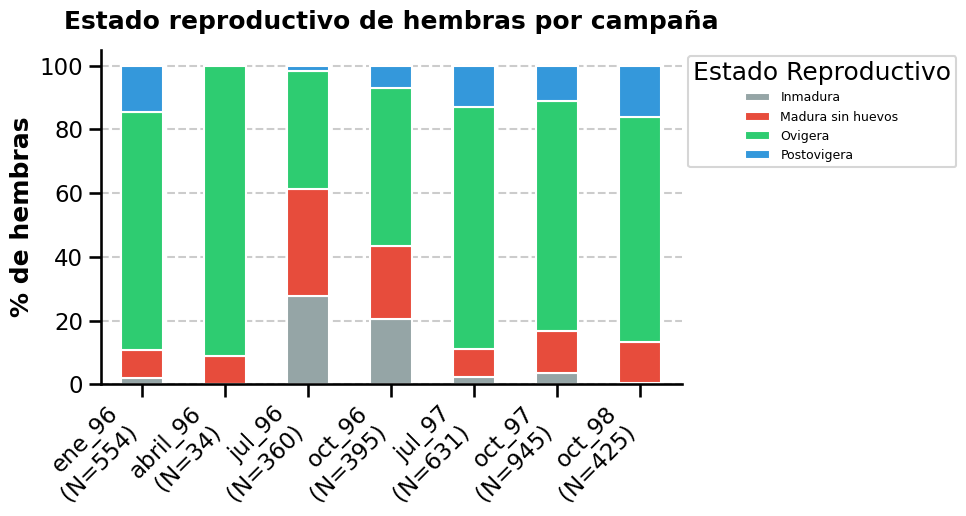

In [39]:
# @title
# Grafico porcentual de estados reproductivos de las hembras

# Tabla de porcentajes y conteos de muestra por campaña
tab_estado = (
    pd.crosstab(
        df_hembras['fecha'],
        df_hembras['estado_reproductivo'],
        normalize='index',
    )
    * 100
)

n_por_campana = (
    df_hembras.groupby('fecha', observed=False)
    .size()
    .reindex(orden_campanas)
    .fillna(0)
)

# Paleta de 4 colores representativos para la visualización
# Gris (Inmadura), Rojo/Naranja (Madura s/huevos), Verde (Ovígera), Azul (Postovígera)
colores_estado = ['#95a5a6', '#e74c3c', '#2ecc71', '#3498db']

fig, ax = plt.subplots(figsize=(10, 5.5))

tab_estado.plot(
    kind='bar', stacked=True, ax=ax, color=colores_estado, edgecolor='white'
)

# Etiquetas con tamaño muestral (N)
etiquetas = [
    f'{t}\n(N={int(n_por_campana[t])})' for t in orden_campanas
]
ax.set_xticklabels(etiquetas, rotation=45, ha='right')

ax.set_xlabel('')
ax.set_ylabel('% de hembras', fontweight='bold')
ax.set_title(
    'Estado reproductivo de hembras por campaña', fontweight='bold', pad=15
)
ax.legend(
    title='Estado Reproductivo',
    bbox_to_anchor=(1, 1),
    loc='upper left',
    fontsize=9,
)

sns.despine()
ax.set_axisbelow(True)
plt.grid(axis='y', linestyle='--', alpha=0.4, color='gray')
plt.tight_layout()
plt.show()

In [40]:
# Tabla de frecuencias absolutas
tabla_conteo = pd.crosstab(
    df_hembras['fecha'],
    df_hembras['estado_reproductivo'],
    dropna=False,
)

tabla_conteo['Total Hembras'] = tabla_conteo.sum(axis=1)

# Salida tabulada
print(tabla_conteo.to_string())

estado_reproductivo  Inmadura  Madura sin huevos  Ovigera  Postovigera  Total Hembras
fecha                                                                                
ene_96                     11                 49      414           80            554
abril_96                    0                  3       31            0             34
jul_96                    100                121      133            6            360
oct_96                     81                 91      196           27            395
jul_97                     14                 57      478           82            631
oct_97                     35                123      683          104            945
oct_98                      2                 55      299           69            425


**Interpretación:** Se observa que las campañas de julio y octubre del 96 han reportado cantidades elevadas de hembras sin huevos (entre el 65% y el 45%, sobre un volumen aproximado de 380-420 hembras). El 90% de hembras ovígeras reportado en abril de ese año no es comparable debido al volumen sobre el cual se calcula, siendo este de un orden de magnitud menor al de las demás campañas. El porcentaje asociado a hembras maduras sin huevos es un indicador de posibles fallas de fecundación o periodos intermuda.

Por otro lado, las temporadas que mayor presencia de huevos muestran son octubre y julio del 97, y enero del 96.

Puesto que el ciclo reproductivo del centollón dura entre 18 y 22 meses, no es de extrañar que la mayor presencia de huevos esté distribuída a lo largo del año. Esto es debido a que los individuos pescados pueden pertenecer a periodos distintos de fecundación.

En la campaña de enero del 96 y de julio del 97 en adelante se observa que la proporción de hembras fértiles cursando su ciclo reproductivo favorablemente se mantiene, las cuales representan más del 80% del total de hembras capturadas.

### 5.2 ¿Qué localizaciones del Canal Beagle constituyen áreas críticas de incubación al registrar las mayores densidades ($IAR$) y proporciones de hembras ovígeras?

**Planteo e implicancias:** El análisis espacial de las capturas de hembras de centollón en estadios ovígero y postovígero permite identificar los Hábitats Marinos Esenciales para la conservación del recurso en el Canal Beagle. Determinar las áreas con mayor densidad relativa de hembras reproductoras ($IAR_{hembra}$) es fundamental para definir las zonas geográficos de preferencia para la incubación, el desove y la posterior liberación larvaria. La existencia de sitios con estas características sugiere una segregación espacial poblacional guiada por requerimientos ambientales, batimétricos y de sustrato específicos.

Esta evaluación cobra vital importancia debido al ciclo reproductivo bienal de la especie, donde las hembras incuban embriones durante 18 a 22 meses. Esta prolongada fase las expone de manera continua a la captura incidental (bycatch). Aunque la normativa exige su devolución inmediata, el izado de las trampas, el estrés por emersión y la manipulación en cubierta provocan la pérdida mecánica de huevos y afectan la viabilidad embrionaria. El impacto es aún mayor en ejemplares postovígeros, los cuales, al encontrarse en fase de muda con exoesqueleto blando previa a la cópula, sufren una elevada mortalidad por descarte.

En consecuencia, la prohibición de retención resulta insuficiente si la flota opera sobre los principales focos de concentración reproductiva. Identificar con precisión estas zonas permite pasar de una restricción genérica a un esquema de ordenamiento espacial, fundamentando la creación de vedas temporales o polígonos de resguardo que protejan la renovación de la biomasa sin paralizar innecesariamente la pesquería comercial.

**Desarrollo:** ...

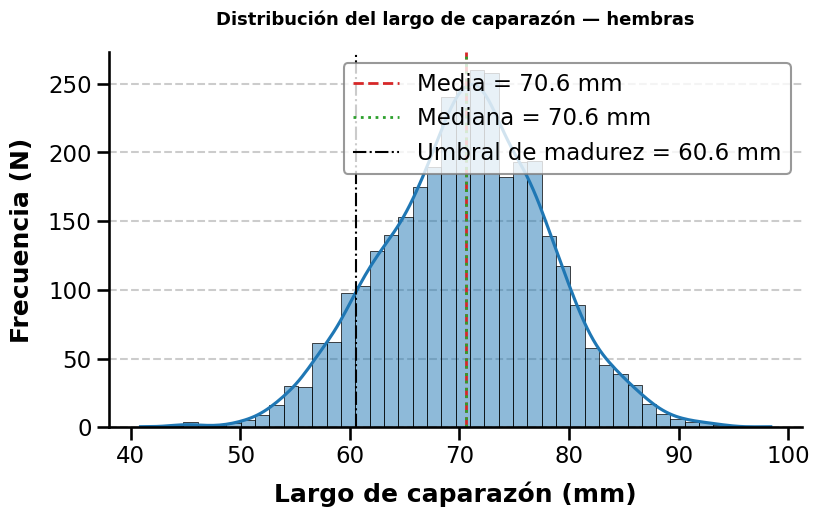

In [41]:
media_largo_hem = df_hembras['largo_caparazon'].mean()
mediana_largo_hem = df_hembras['largo_caparazon'].median()

plt.close('all')
fig, ax = plt.subplots(figsize=(9, 5.5))

sns.histplot(df_hembras['largo_caparazon'], kde=True, color='#1f77b4',
             edgecolor='black', linewidth=0.5, ax=ax)

ax.axvline(media_largo_hem, color='#d62728', linestyle='--', linewidth=2,
           label=f'Media = {media_largo_hem:.1f} mm')
ax.axvline(media_largo_hem, color='#2ca02c', linestyle=':', linewidth=2,
           label=f'Mediana = {media_largo_hem:.1f} mm')
ax.axvline(60.6, color='black', linestyle='-.', linewidth=1.5,
           label='Umbral de madurez = 60.6 mm')

ax.set_xlabel('Largo de caparazón (mm)', fontweight='bold', labelpad=10)
ax.set_ylabel('Frecuencia (N)', fontweight='bold', labelpad=10)
ax.set_title('Distribución del largo de caparazón — hembras', fontsize=13,
             fontweight='bold', pad=20)
ax.legend(frameon=True, facecolor='white', edgecolor='gray', loc='upper right')

sns.despine()
ax.set_axisbelow(True)
ax.grid(axis='y', linestyle='--', alpha=0.4, color='gray')

plt.tight_layout(pad=2.0)  # más aire alrededor de toda la figura
plt.subplots_adjust(bottom=0.15)  # más espacio debajo del gráfico, antes de que termine la celda
plt.show()

In [42]:
# Calculo de IAR_hembras

# Defino estadios vulnerables
cod_vulnerables = [1, 2, 3, 30, 4, 40, 5, 6, 7]

# Agrupacion por evento desde el dataset completo (df_clean)
df_eventos_hembras = (
    df_segmented[df_segmented['num_trampas'] > 0]
    .groupby(['localizacion', 'fecha', 'tipo'], observed=False)
    .agg(
        n_trampas=('num_trampas', 'first'),
        n_hembras_totales=(
            'sexo',
            lambda s: (s.isin([2, 'Hembra'])).sum(),
        ),
        n_hembras_vulnerables=(
            'huevos',
            lambda h: h.isin(cod_vulnerables).sum(),
        ),
    )
    .reset_index()
)

# Consolidad por Localización
loc_summary = (
    df_eventos_hembras.groupby('localizacion', observed=False)
    .agg(
        N_Trampas=('n_trampas', 'sum'),
        N_Hembras=('n_hembras_totales', 'sum'),
        N_Vulnerables=('n_hembras_vulnerables', 'sum'),
    )
    .reset_index()
)

# Indicadores Clave
loc_summary['IAR_hembra'] = loc_summary['N_Hembras'] / loc_summary['N_Trampas']
loc_summary['pct_vulnerables'] = np.where(
    loc_summary['N_Hembras'] > 0,
    (loc_summary['N_Vulnerables'] / loc_summary['N_Hembras']) * 100,
    0,
)

In [43]:
# Clasificador Cuaternario (vulnerabilidad reproductiva)
# Umbral Biológico Absoluto para Vulnerabilidad (> 60%)
umbral_pct_vulnerable = 50.0

# Umbral Estadístico de Alta Densidad (Top 30%)
umbral_iar_alto = loc_summary['IAR_hembra'].quantile(0.70)


def clasificar_zona_rigurosa(row):
  if (
      row['IAR_hembra'] >= umbral_iar_alto
      and row['pct_vulnerables'] >= umbral_pct_vulnerable
  ):
    return '1. Roja (Hotspot Reproductivo Crítico)'
  elif (
      row['IAR_hembra'] >= umbral_iar_alto
      and row['pct_vulnerables'] < umbral_pct_vulnerable
  ):
    return '2. Amarilla (Alta Densidad / Baja Vulnerabilidad)'
  elif (
      row['IAR_hembra'] < umbral_iar_alto
      and row['pct_vulnerables'] >= umbral_pct_vulnerable
  ):
    return '3. Verde (Vulnerable Dispersa / Refugio)'
  else:
    return '4. Gris (Baja Densidad General)'


loc_summary['Categoria_Zona'] = loc_summary.apply(
    clasificar_zona_rigurosa, axis=1
)

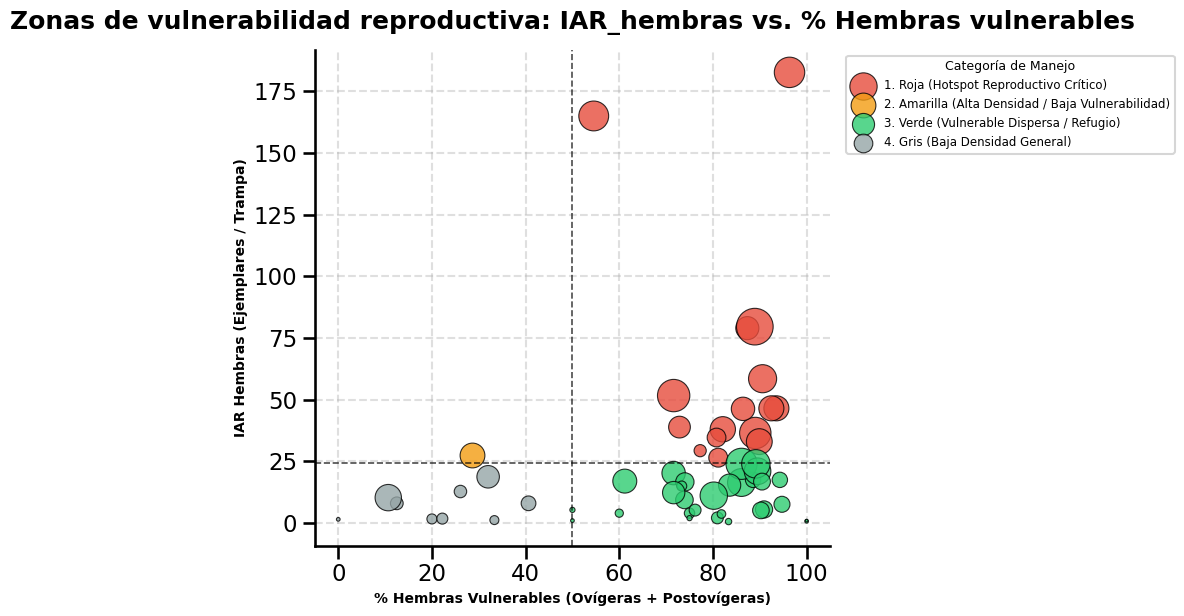

In [44]:
plt.close('all')
fig, ax = plt.subplots(figsize=(10, 6.5))

# Paleta de colores para las 4 zonas de vulnerabilidad
colores = {
    '1. Roja (Hotspot Reproductivo Crítico)': '#E74C3C',
    '2. Amarilla (Alta Densidad / Baja Vulnerabilidad)': '#F39C12',
    '3. Verde (Vulnerable Dispersa / Refugio)': '#2ECC71',
    '4. Gris (Baja Densidad General)': '#95A5A6',
}

# Representación grafica por categoría
for clase, grupo in loc_summary.groupby('Categoria_Zona', observed=False):
  if not grupo.empty:
    ax.scatter(
        grupo['pct_vulnerables'],
        grupo['IAR_hembra'],
        s=grupo['N_Hembras'] * 3.5,  # Escala visual por tamaño de muestra
        color=colores.get(clase, 'gray'),
        edgecolor='black',
        linewidth=0.8,
        alpha=0.8,
        label=clase,
    )

# 4. Trazado de líneas divisoras de los 4 cuadrantes de gestión
ax.axvline(
    umbral_pct_vulnerable,
    color='black',
    linestyle='--',
    linewidth=1.2,
    alpha=0.7,
)
ax.axhline(
    umbral_iar_alto, color='black', linestyle='--', linewidth=1.2, alpha=0.7
)

# 5. Formato de ejes y leyenda
ax.set_xlabel(
    '% Hembras Vulnerables (Ovígeras + Postovígeras)',
    fontweight='bold',
    fontsize=10,
)
ax.set_ylabel(
    'IAR Hembras (Ejemplares / Trampa)', fontweight='bold', fontsize=10
)
ax.set_title(
    'Zonas de vulnerabilidad reproductiva: IAR_hembras vs. % Hembras'
    ' vulnerables',
    fontweight='bold',
    pad=15,
)

ax.legend(
    title='Categoría de Manejo',
    fontsize=8.5,
    title_fontsize=9,
    loc='upper left',
    bbox_to_anchor=(1.02, 1),
    frameon=True,
)

sns.despine()
ax.set_axisbelow(True)
plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

### 5.3 ¿Existe una relación estadísticamente significativa entre el Índice de Abundancia Relativa específico de machos ($IAR_{macho}$) y su talla de caparazón ($L$) en las poblaciones de centollón (Paralomis granulosa) del Canal Beagle?

**Planteo e implicancias:** En fases iniciales se analizó la relación entre el $IAR$ global y la talla media de todos los ejemplares capturados, detectándose una correlación negativa significativa ($r = -0.331, p = 0.018$). Este patrón sugería que las zonas con mayor densidad actuaban como áreas de cría o reclutamiento (ejemplares más pequeños). Sin embargo, al incorporar la campaña de julio de 1997, la correlación se diluyó ($r = -0.108, p = 0.422$), perdiendo significancia estadística.

El análisis poblacional reveló que este debilitamiento se debió a un sesgo metodológico: el dimorfismo sexual de la especie implica que las hembras presentan, en promedio, una talla de caparazón sensiblemente menor a la de los machos. En consecuencia, las localizaciones con alta proporción de hembras reducían artificialmente la talla media global, confundiendo la estructura demográfica con la abundancia real.

Dado que la función de esfuerzo $T$ (número de trampas por lance) es una constante del evento de muestreo y no depende del individuo, el índice general posee propiedad aditiva:

\$$IAR_{total} = \frac{N_{total}}{T} = \frac{N_{macho} + N_{hembra}}{T} = \frac{N_{macho}}{T} + \frac{N_{hembra}}{T} = IAR_{macho} + IAR_{hembra}$$

Puesto que rige el principio de cero retención para hembras, evaluar la abundancia mediante $IAR_{total}$ distorsiona el indicador de biomasa comercializable. Aislar $IAR_{macho}$ permite monitorear exclusivamente la fracción sobre la que recae el esfuerzo extractivo.

Por otro lado, evaluar la relación talla-densidad únicamente en machos permite determinar si existen parches espaciales de agregación de juveniles ($< 50.2\text{ mm}$) que requieran vedas geográficas temporales para prevenir la captura incidental y la mortalidad por descarte.

**Desarrollo:** Se filtra el dataframe de trabajo a registros válidos de machos. Con esto, se hace una descripción de eventos muestrales considerando su localización, fecha y tipo, a partir de los cuales se analiza la existencia de relación entre la variable $IAR_{macho}$ y la talla del recurso pesquero.



In [45]:
# Subconjunto de machos
df_machos = df_segmented[(df_segmented['sexo'] == 1)].copy()

# Tamaño del subconjunto
print(f"Filas: {df_machos.shape[0]:,} | Columnas: {df_machos.shape[1]}")

Filas: 5,444 | Columnas: 17


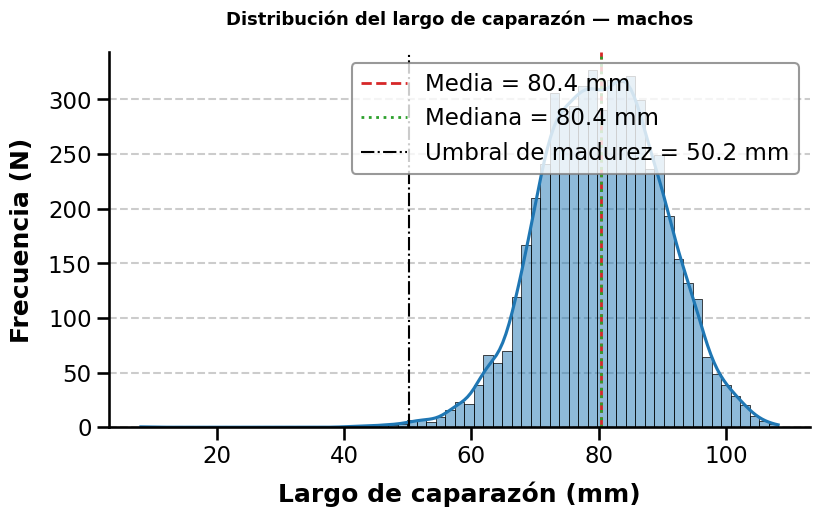

In [46]:
media_largo = df_machos['largo_caparazon'].mean()
mediana_largo = df_machos['largo_caparazon'].median()

plt.close('all')
fig, ax = plt.subplots(figsize=(9, 5.5))

sns.histplot(df_machos['largo_caparazon'], kde=True, color='#1f77b4',
             edgecolor='black', linewidth=0.5, ax=ax)

ax.axvline(media_largo, color='#d62728', linestyle='--', linewidth=2, label=f'Media = {media_largo:.1f} mm')
ax.axvline(mediana_largo, color='#2ca02c', linestyle=':', linewidth=2, label=f'Mediana = {mediana_largo:.1f} mm')
ax.axvline(50.2, color='black', linestyle='-.', linewidth=1.5, label='Umbral de madurez = 50.2 mm')

ax.set_xlabel('Largo de caparazón (mm)', fontweight='bold', labelpad=10)
ax.set_ylabel('Frecuencia (N)', fontweight='bold', labelpad=10)
ax.set_title('Distribución del largo de caparazón — machos', fontsize=13, fontweight='bold', pad=20)
ax.legend(frameon=True, facecolor='white', edgecolor='gray', loc='upper right')

sns.despine()
ax.set_axisbelow(True)
ax.grid(axis='y', linestyle='--', alpha=0.4, color='gray')

plt.tight_layout(pad=2.0)  # más aire alrededor de toda la figura
plt.subplots_adjust(bottom=0.15)  # más espacio debajo del gráfico, antes de que termine la celda
plt.show()

***Figura 1.** Distribución del largo de caparazón de los machos de Paralomis granulosa, con líneas de referencia para la media general, la mediana, el umbral de madurez sexual (50.2 mm).*

In [47]:
# Calculo de IAR_machos
# Calculo por evento usando el mismo esfuerzo total, pero contando solo machos
iar_data_machos = []
for (loc, fecha, tipo), group in df_machos.groupby(
    ['localizacion', 'fecha', 'tipo'], observed=True
):
  num_capturas = len(group)
  num_trampas_evento = group['num_trampas'].iloc[0]
  iar = num_capturas / num_trampas_evento if num_trampas_evento > 0 else 0
  iar_data_machos.append({
      'Localización': loc,
      'N_Capturas_machos': num_capturas,
      'N_Trampas': num_trampas_evento,
      'IAR_machos': iar,
  })

df_iar_machos = pd.DataFrame(iar_data_machos)

iar_machos_por_loc = df_iar_machos.groupby('Localización', observed=False).agg(
    N_Capturas_machos=('N_Capturas_machos', 'sum'),
    N_Trampas=('N_Trampas', 'sum'),
)
iar_machos_por_loc['IAR_machos'] = (
    iar_machos_por_loc['N_Capturas_machos'] / iar_machos_por_loc['N_Trampas']
)

# Recalculo de talla_iar usando IAR_machos en vez de IAR_Total
talla_por_loc = df_machos.groupby('localizacion', observed=False).agg(
    talla_media=('largo_caparazon', 'mean'),
    n_machos=('largo_caparazon', 'count'),
)

talla_iar_machos = talla_por_loc.join(
    iar_machos_por_loc[['IAR_machos']], how='inner'
).sort_values('talla_media')

print(
    'Localizaciones ordenadas por menor talla media de machos (con'
    ' IAR_machos):'
)
print(talla_iar_machos.round(3).to_string())

Localizaciones ordenadas por menor talla media de machos (con IAR_machos):
                                                  talla_media  n_machos  IAR_machos
localizacion                                                                       
wp 32                                                  73.490       161      89.444
entre Yunque y Martillo                                73.758       192      19.200
wp 168                                                 73.788       113      28.250
WP 59                                                  75.410       215     107.500
E I. Martillo                                          75.564       448     135.758
wp 244                                                 75.721       141     141.000
 frente bal. Ponsatti                                  76.156        79      26.333
wp 162                                                 76.387        79      19.750
wp 60                                                  76.396       166      55.333
w

In [64]:
mediana_iar_machos = talla_iar_machos['IAR_machos'].median()
talla_media_general = talla_iar_machos['talla_media'].mean()

def clasificar(row):
    alto_iar = row['IAR_machos'] >= mediana_iar_machos
    talla_chica = row['talla_media'] < talla_media_general
    if alto_iar and talla_chica:
        return 'ALTO IAR_machos + talla chica (evitar pesca)'
    elif alto_iar and not talla_chica:
        return 'ALTO IAR_machos + talla grande (pesca sostenible)'
    elif not alto_iar and talla_chica:
        return 'Bajo IAR_machos + talla chica'
    else:
        return 'Bajo IAR_machos + talla grande'

talla_iar_machos['clasificacion'] = talla_iar_machos.apply(clasificar, axis=1)
print(talla_iar_machos[['talla_media','IAR_machos','n_machos','clasificacion']].sort_values('IAR_machos', ascending=False).to_string())

                                                  talla_media  IAR_machos  n_machos                                      clasificacion
localizacion                                                                                                                          
wp 157                                              76.881343  178.666667       134       ALTO IAR_machos + talla chica (evitar pesca)
wp 159                                              80.914179  178.666667       134       ALTO IAR_machos + talla chica (evitar pesca)
wp 238                                              90.553571  168.000000        84  ALTO IAR_machos + talla grande (pesca sostenible)
wp 244                                              75.720567  141.000000       141       ALTO IAR_machos + talla chica (evitar pesca)
E I. Martillo                                       75.563839  135.757576       448       ALTO IAR_machos + talla chica (evitar pesca)
wp 33                                               76.

In [65]:
r_machos_correcto, p_machos_correcto = stats.pearsonr(
    talla_iar_machos['talla_media'], talla_iar_machos['IAR_machos']
    )

print(f"Correlación talla vs IAR_machos (corregida): r={r_machos_correcto:.3f},\
  p={p_machos_correcto:.4f}, n={len(talla_iar_machos)}")

Correlación talla vs IAR_machos (corregida): r=-0.252,  p=0.0586, n=57


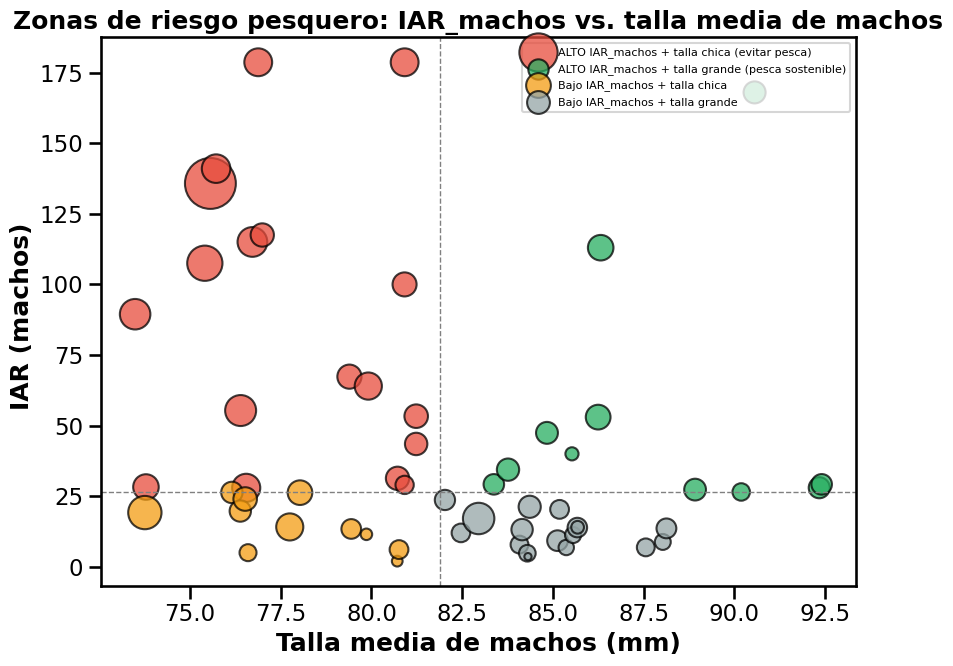

In [70]:
plt.close('all')
fig, ax = plt.subplots(figsize=(9,7))

colores = {
    'ALTO IAR_machos + talla chica (evitar pesca)': '#E74C3C',
    'ALTO IAR_machos + talla grande (pesca sostenible)': '#27AE60',
    'Bajo IAR_machos + talla chica': '#F39C12',
    'Bajo IAR_machos + talla grande': '#95A5A6'
}

mediana_iar_machos_local = talla_iar_machos['IAR_machos'].median()
talla_media_general_machos = talla_iar_machos['talla_media'].mean()

for clase, grupo in talla_iar_machos.groupby('clasificacion'):
    ax.scatter(grupo['talla_media'], grupo['IAR_machos'], s=grupo['n_machos']*3,
               color=colores.get(clase, 'gray'), edgecolor='black', alpha=0.75, label=clase)

ax.axvline(talla_media_general_machos, color='gray', linestyle='--', linewidth=1)
ax.axhline(mediana_iar_machos_local, color='gray', linestyle='--', linewidth=1)
ax.set_xlabel('Talla media de machos (mm)', fontweight='bold')
ax.set_ylabel('IAR (machos) ', fontweight='bold')
ax.set_title('Zonas de riesgo pesquero: IAR_machos vs. talla media de machos', fontweight='bold')
ax.legend(fontsize=8, loc='upper right')
plt.tight_layout()
plt.show()

***Figura 6.** Zona de riesgo: $IAR_{machos}$  vs. talla media de machos.*

Al visualizar la relación entre el Índice de Abundancia Relativa de machos ($IAR_{machos}$) y la talla media de caparazón por localización, se observa una tendencia visual: las localizaciones con mayor $IAR_{machos}$ (puntos rojos, por encima de la mediana) se concentran predominantemente en el rango de tallas menores a la media general ($~82 mm$), mientras que las localizaciones con menor $IAR_{machos}$ tienden a distribuirse en un rango de tallas más amplio, incluyendo valores por encima de la media. Esta observación es consistente con la correlación negativa calculada previamente ($r=-0.252, p=0.059$).

In [71]:
coords_por_loc = df_segmented.dropna(subset=['latitud','longitud']).groupby('localizacion').agg(
    latitud=('latitud','mean'), longitud=('longitud','mean')
).reset_index()

mapa_clasificacion = coords_por_loc.merge(
    talla_iar_machos.reset_index(),  # ← usar la tabla con IAR_machos, no talla_iar
    on='localizacion',
    how='inner'
)

In [72]:
colores_categoria = {
    'ALTO IAR_machos + talla chica (evitar pesca)': '#E74C3C',
    'ALTO IAR_machos + talla GRANDE (pesca sostenible)': '#27AE60',
    'Bajo IAR_machos + talla chica': '#F39C12',
    'Bajo IAR_machos + talla GRANDE': '#95A5A6'
}
fig_mapa_clasif = px.scatter_map(
    mapa_clasificacion,
    lat="latitud",
    lon="longitud",
    color="clasificacion",
    color_discrete_map=colores_categoria,
    size="IAR_machos",
    hover_name="localizacion",
    hover_data={"talla_media": ':.1f', "IAR_machos": ':.1f', "n_machos": True},
    zoom=8,
    map_style="open-street-map"
)

fig_mapa_clasif.update_layout(
    mapbox_bounds={
        "west": mapa_clasificacion.longitud.min(),
        "east": mapa_clasificacion.longitud.max(),
        "south": mapa_clasificacion.latitud.min(),
        "north": mapa_clasificacion.latitud.max()
    },
    legend=dict(yanchor="top", y=0.99, xanchor="left", x=0.01, bgcolor="rgba(255,255,255,0.8)")
)

fig_mapa_clasif.show()

***Figura 7.** Identificación greográfica de puntos con riesgo pesquero.*

Es particularmente relevante que la mayor concentración de puntos rojos ("alto IAR_machos + talla chica, evitar pesca") coincida con el área de mayor indice de abundancia relativa. Esto sugiere que, precisamente en la región donde se concentra la actividad extractiva sobre los machos, existe una proporción considerable de localizaciones donde los machos capturables presentan tallas por debajo del promedio general — un patrón consistente con la posibilidad de que la extracción sostenida en esta zona esté afectando la estructura de tallas disponible.

Cabe recordar que esta clasificación visual se basa en umbrales de mediana/promedio, y que la correlación general entre IAR_machos y talla no alcanzó significancia estadística convencional (r=-0.252, p=0.059). Por lo tanto, el patrón observado en el mapa debe interpretarse como una herramienta de priorización exploratoria para identificar localizaciones puntuales de interés, y no como evidencia concluyente de una relación sistemática entre abundancia y tamaño en toda la zona de estudio.

#### 5.3.1 Estudio por temporada

In [73]:
# Eventos de captura de MACHOS (localización + fecha + tipo)
iar_data_machos_temp = []
for (loc, fecha, tipo), group in df_machos.groupby(['localizacion', 'fecha', 'tipo']):
    num_capturas = len(group)
    num_trampas_evento = group['num_trampas'].iloc[0]
    iar = num_capturas / num_trampas_evento if num_trampas_evento > 0 else 0
    iar_data_machos_temp.append({
        'Localización': loc, 'Fecha': fecha, 'Tipo': tipo,
        'N_Capturas_machos': num_capturas, 'N_Trampas': num_trampas_evento, 'IAR_machos': iar
    })

df_iar_machos_temp = pd.DataFrame(iar_data_machos_temp)

# Agregado por localización y temporada
iar_machos_temporal = df_iar_machos_temp.groupby(['Localización', 'Fecha']).agg(
    N_Capturas_machos=('N_Capturas_machos','sum'), N_Trampas=('N_Trampas','sum')
).reset_index()
iar_machos_temporal['IAR_machos'] = iar_machos_temporal['N_Capturas_machos'] / iar_machos_temporal['N_Trampas']

print(iar_machos_temporal.head())

                                       Localización   Fecha  \
0                              frente bal. Ponsatti  ene_96   
1                                     E I. Martillo  jul_96   
2  N Snipe al traves con la baliza p. de los indios  ene_96   
3                   S islote Belgrano/punta navarro  ene_96   
4                                 SW Ilote Belgrano  ene_96   

   N_Capturas_machos  N_Trampas  IAR_machos  
0                 79        3.0   26.333333  
1                448        3.3  135.757576  
2                 45        4.0   11.250000  
3                 28        2.0   14.000000  
4                 55        7.0    7.857143  


/tmp/ipykernel_672/2129393473.py:3: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



In [74]:
talla_temporal_machos = df_machos.groupby(['localizacion', 'fecha']).agg(
    talla_media=('largo_caparazon', 'mean'),
    n_machos=('largo_caparazon', 'count')
).reset_index()

print(talla_temporal_machos.head())

            localizacion     fecha  talla_media  n_machos
0   frente bal. Ponsatti    ene_96    76.155696        79
1   frente bal. Ponsatti  abril_96          NaN         0
2   frente bal. Ponsatti    jul_96          NaN         0
3   frente bal. Ponsatti    oct_96          NaN         0
4   frente bal. Ponsatti    jul_97          NaN         0


/tmp/ipykernel_672/2262706387.py:1: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



In [75]:
talla_iar_machos_temp = talla_temporal_machos.merge(
    iar_machos_temporal,
    left_on=['localizacion','fecha'], right_on=['Localización','Fecha'],
    how='inner'
)

print(f"Columnas: {talla_iar_machos_temp.columns.tolist()}")

Columnas: ['localizacion', 'fecha', 'talla_media', 'n_machos', 'Localización', 'Fecha', 'N_Capturas_machos', 'N_Trampas', 'IAR_machos']


In [76]:
talla_iar_machos_temp['mediana_iar_temp'] = talla_iar_machos_temp.groupby('fecha')['IAR_machos'].transform('median')
talla_iar_machos_temp['talla_media_temp'] = talla_iar_machos_temp.groupby('fecha')['talla_media'].transform('mean')

def clasif(row):
    alto_iar = row['IAR_machos'] >= row['mediana_iar_temp']
    talla_chica = row['talla_media'] < row['talla_media_temp']
    if alto_iar and talla_chica:
        return 'ALTO IAR_machos + talla chica'
    elif alto_iar and not talla_chica:
        return 'ALTO IAR_machos + talla grande'
    elif not alto_iar and talla_chica:
        return 'Bajo IAR_machos + talla chica'
    else:
        return 'Bajo IAR_machos + talla grande'

talla_iar_machos_temp['clasificacion'] = talla_iar_machos_temp.apply(clasif, axis=1)

print(talla_iar_machos_temp[['localizacion','fecha','talla_media','IAR_machos','clasificacion']].to_string(index=False))

                                    localizacion    fecha  talla_media  IAR_machos                  clasificacion
                            frente bal. Ponsatti   ene_96    76.155696   26.333333  ALTO IAR_machos + talla chica
                                   E I. Martillo   jul_96    75.563839  135.757576  ALTO IAR_machos + talla chica
N Snipe al traves con la baliza p. de los indios   ene_96    85.553333   11.250000 Bajo IAR_machos + talla grande
                 S islote Belgrano/punta navarro   ene_96    85.678571   14.000000 ALTO IAR_machos + talla grande
                               SW Ilote Belgrano   ene_96    84.078182    7.857143 Bajo IAR_machos + talla grande
                                           WP 59   oct_96    75.410233  107.500000  ALTO IAR_machos + talla chica
                                           WP 63   oct_96    79.443284   13.400000 ALTO IAR_machos + talla grande
                                           WP 65   oct_96    78.031429   26.250000  ALTO

In [77]:
coords_por_loc = df_segmented.dropna(subset=['latitud','longitud']).groupby('localizacion').agg(
    latitud=('latitud','mean'), longitud=('longitud','mean')
).reset_index()

colores_categoria = {
    'ALTO IAR_machos + talla chica': '#E74C3C',
    'ALTO IAR_machos + talla grande': '#27AE60',
    'Bajo IAR_machos + talla chica': '#F39C12',
    'Bajo IAR_machos + talla grande': '#95A5A6'
}

mapa_temporal_machos = talla_iar_machos_temp.merge(coords_por_loc, on='localizacion', how='inner')

orden_fechas = ['ene_96','abril_96','jul_96','oct_96','jul_97','oct_97','oct_98']
mapa_temporal_machos['fecha'] = pd.Categorical(mapa_temporal_machos['fecha'], categories=orden_fechas, ordered=True)
mapa_temporal_machos = mapa_temporal_machos.sort_values('fecha')

categorias_completas = list(colores_categoria.keys())

fig_animado_machos = px.scatter_map(
    mapa_temporal_machos,
    lat="latitud", lon="longitud",
    color="clasificacion",
    color_discrete_map=colores_categoria,
    category_orders={"clasificacion": categorias_completas},
    size="IAR_machos",
    hover_name="localizacion",
    hover_data={"talla_media": ':.1f', "IAR_machos": ':.1f', "n_machos": True},
    animation_frame="fecha",
    zoom=8,
    map_style="open-street-map"
)

fig_animado_machos.update_layout(
    mapbox_bounds={
        "west": mapa_temporal_machos.longitud.min(), "east": mapa_temporal_machos.longitud.max(),
        "south": mapa_temporal_machos.latitud.min(), "north": mapa_temporal_machos.latitud.max()
    }
)
fig_animado_machos.show()

***Figura 7.** Evolución de zonas de riesgo pesquero (machos) por temporada.*


Es notable que, en las temporadas donde aparecen localizaciones "verdes" (jul_97 y oct_98), estas tienden a ubicarse más hacia el oeste del canal (más alejadas de Puerto Williams), mientras que los puntos rojos de mayor tamaño se concentran consistentemente en el tramo central, en las inmediaciones de esa localidad. Esto podría sugerir una asociación entre la proximidad a la zona de mayor actividad/muestreo (Puerto Williams) y la persistencia de una estructura de tallas de machos por debajo del promedio, aunque esta observación requeriría un análisis específico de la relación entre distancia a Puerto Williams e IAR_machos para confirmarse.